# Import modules

In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Model PINN

In [2]:
class simpleModel(nn.Module):
  def __init__(self,
               hidden_size=20):
    super().__init__()
    self.layers_stack = nn.Sequential(
        nn.Linear(1, hidden_size),
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #1
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #2
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #3
        nn.Tanh(),
        nn.Linear(hidden_size, hidden_size), #4
        nn.Tanh(),
        nn.Linear(hidden_size, 1),
        nn.Tanh(),
    )

  def forward(self, x):
    return self.layers_stack(x)

# PDE of the motion of harmonic oscillator

In [3]:
def pde(out, t, omega):
    # первая производная 
    dxdt = torch.autograd.grad(out, t, 
                               torch.ones_like(t), 
                               create_graph=True,   # создать граф    
                               retain_graph=True    # сохранить граф 
    )[0]
    # вторая производная 
    d2xdt2 = torch.autograd.grad(dxdt, t, 
                                 torch.ones_like(t), 
                                 create_graph=True, 
                                 retain_graph=True
    )[0]
    # невязка
    return d2xdt2 + (omega ** 2) * out

# Parameters of the task

In [4]:
def pdeBC(t, omega, x0_true, dx0dt_true):
    out = model(t).to(device)            # делаем предсказание 
    f1 = pde(out, t, omega)              # считаем остаток 

    # граничные условия 
    inlet_mask = (t[:, 0] == 0)
    t0 = t[inlet_mask]
    x0 = model(t0).to(device)
    dx0dt = torch.autograd.grad(x0, t0, 
                                torch.ones_like(t0), 
                                create_graph=True, 
                                retain_graph=True
    )[0]

    # сравнение с аналитическим решением 
    metric_x = metric_data(out, x0_true * torch.sin(omega*t + torch.pi / 2))
    # и с граничными условиями 
    metric_x0 = metric_data(x0, x0_true)
    metric_dx0dt = metric_data(dx0dt, dx0dt_true.to(device))

    # лосс по начальным условиям:
    #  - штрафует за отклонение x(0) от x0_true (начальное положение)
    #  - и за отклонение dx/dt(0) от dx0dt_true (начальная скорость)
    loss_bc = metric_x0 + metric_dx0dt
    # лосс на уравнение ПУ: штрафует за отклонение residual f1 от нуля
    loss_pde = metric_data(f1, torch.zeros_like(f1))

    loss = 1e3*loss_bc + loss_pde

    metrics = {'loss': loss,
               'loss_bc': metric_x0 + metric_dx0dt,
               'loss_pde': loss_pde,
                }

    return loss, metrics

In [ ]:
# создаем модель 
model = simpleModel().to(device)

# параметры 
nu=2
omega = 2 * torch.pi * nu
steps=200

# граничные условия 
x0_true=torch.tensor([1], dtype=float).float().to(device)
dx0dt_true=torch.tensor([0], dtype=float).float().to(device)

# задаем переменные и прогресс-бар
pbar = tqdm(range(steps), desc='Training Progress')
t = (torch.linspace(0, 1, 100).unsqueeze(1)).to(device)
t.requires_grad = True

# метрика и оптимизатор 
metric_data = nn.MSELoss()
optimizer = torch.optim.LBFGS(model.parameters(), lr=0.1)

def train():
    metrics = []
    for step in pbar:

        def closure():
            optimizer.zero_grad()
            loss, metric = pdeBC(t, omega, x0_true, dx0dt_true)
            metrics.append(metric)
            loss.backward()
            return loss

        optimizer.step(closure)
        if step % 2 == 0:
            current_loss = closure().item()
            pbar.set_description("Step: %d | Loss: %.6f" %
                                 (step, current_loss))
    return metrics

metrics = train()

Training Progress:   0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Step: 4 | Loss: 889.736145:   3%|▎         | 6/200 [00:16<08:04,  2.50s/it]

In [ ]:
loss = []
loss_bc = []
loss_pde = []

for step in metrics:
    loss.append(step['loss'].item()) 
    loss_bc.append(step['loss_bc'].item())
    loss_pde.append(step['loss_pde'].item())

# Predict values

In [ ]:
fs=13 # размер шрифта 

x_pred = model(t.float())
x_true = x0_true * torch.cos(omega*t)

dxdt = torch.autograd.grad(x_pred, t, torch.ones_like(t), create_graph=True, retain_graph=True)[0]
dxdt_true = -x0_true*omega * torch.sin(omega*t)

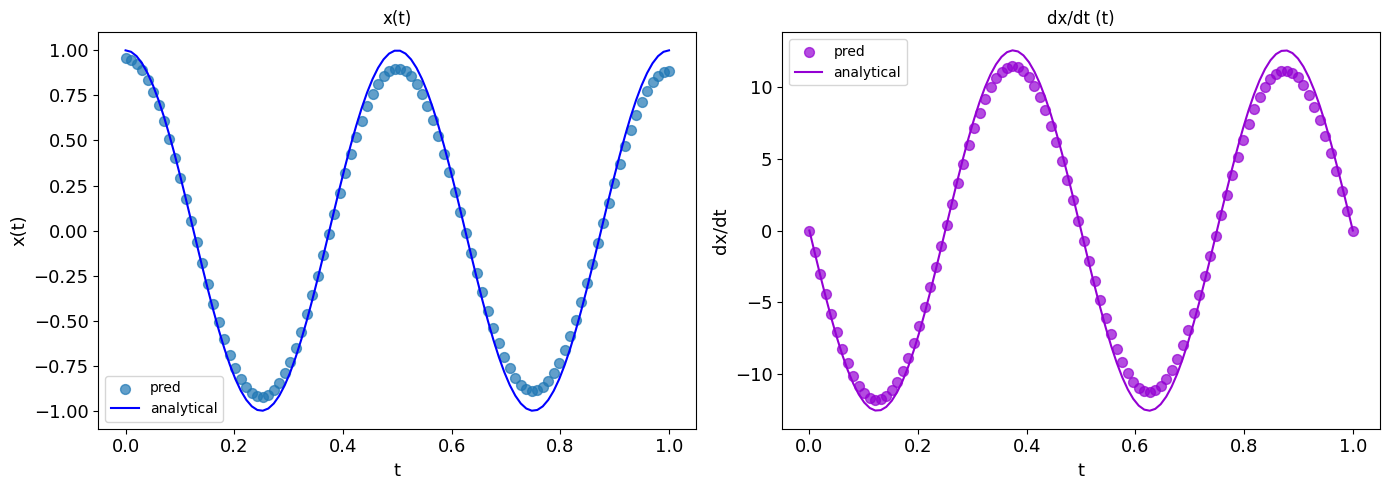

In [ ]:
t_np = t[0].cpu().detach().numpy()
x_pred_np = x_pred[0].cpu().detach().numpy()
x_true_np = x_true[0].cpu().detach().numpy()
dxdt_np = dxdt.cpu().detach().numpy()[0]                                
dxdt_true_np = dxdt_true[0].cpu().detach().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: x(t)
ax1.scatter(t_np, x_pred_np,
            label='pred',
            marker='o',
            alpha=0.7,
            s=50)
ax1.plot(t_np, x_true_np,
         color='blue',
         label='analytical')
ax1.set_xlabel('t', fontsize=fs)
ax1.set_ylabel('x(t)', fontsize=fs)
ax1.tick_params(axis='both', labelsize=fs)
ax1.legend()
ax1.set_title('x(t)')

# Правый график: dx/dt(t)
ax2.scatter(t_np, dxdt_np,
            label='pred',
            marker='o',
            alpha=0.7,
            s=50,
            color='darkviolet')
ax2.plot(t_np, dxdt_true_np,
         color='darkviolet',
         label='analytical')
ax2.set_xlabel('t', fontsize=fs)
ax2.set_ylabel('dx/dt', fontsize=fs)
ax2.tick_params(axis='both', labelsize=fs)
ax2.legend()
ax2.set_title('dx/dt (t)')

plt.tight_layout()
plt.savefig('x_and_dxdt.png', dpi=200)
plt.show()

# history

C:\Users\user\AppData\Local\Temp\ipykernel_11732\777675840.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(min(loss)-2*np.std(loss), max(loss)+2*np.std(loss))


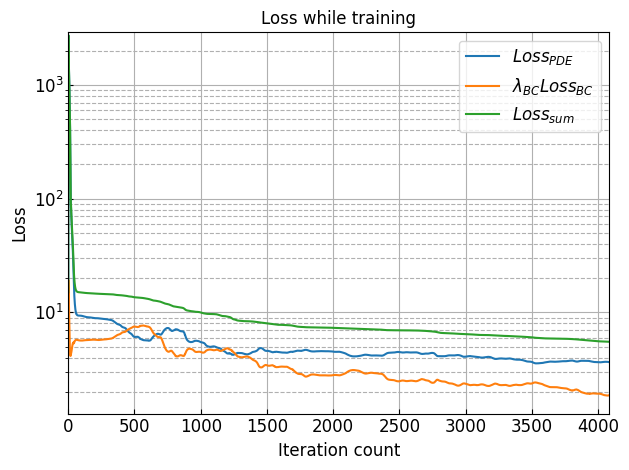

In [ ]:
plt.plot(loss_pde, label=r'$Loss_{PDE}$')
plt.plot([1e3*i for i in loss_bc], label=r'$\lambda_{BC}Loss_{BC}$')
plt.plot(loss, label=r'$Loss_{sum}$')

ax=plt.gca()
ax.set_yscale('log')
plt.grid(which='major', linestyle='-')
plt.grid(which='minor', linestyle='--')
plt.xlim(0, len(loss))
plt.ylim(min(loss)-2*np.std(loss), max(loss)+2*np.std(loss))
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
ax.tick_params(axis='both',direction='in')

plt.legend(fontsize=fs)
plt.xlabel('Iteration count', fontsize=fs)
plt.ylabel('Loss', fontsize=fs)
plt.title('Loss while training')
plt.tight_layout()
plt.savefig('history_harm.png')
plt.show()